## 18.3 Model Fitting

Results for ExampleData1.txt:
  alpha (slope)     = 1.4724508923008977
  beta  (intercept) = 5.64403527651654
  R^2               = 0.9940518317731084

Results for ExampleData2.txt:
  alpha (slope)     = -0.010488669283904318
  beta  (intercept) = 567.0086239265797
  R^2               = 2.451745433340591e-07



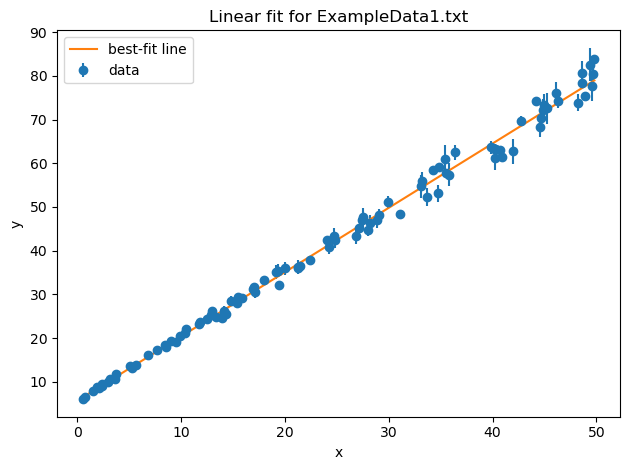

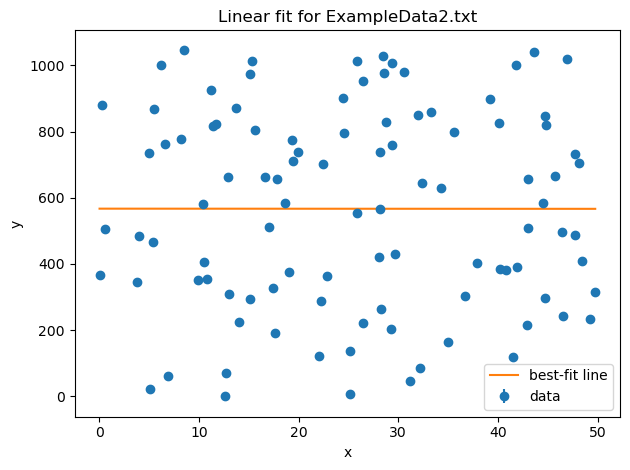

In [193]:
# 1.  Using any python approach of your choice that explicitly only performs linear regression

import numpy as np
import matplotlib.pyplot as plt

def linear_fit(x, y):
    """
    Description:
        Calculates best-fit slope and intercept for linear model y = a*x + b 
        using the unweighted least-squares method. Also computes R^2 value
        to quantify the "goodness" of fit.

    Inputs:
        x (1-D numpy array of x-values)
        y (1-D numpy arrayv of y-values corresponding to x)

    Outputs:
        a (Best-fit slope of the line)
        b (Best-fit intercept of the line)
        R2 (to measure goodness of fit)
    """
    xm = np.mean(x)        # mean of x values
    ym = np.mean(y)        # mean of y values

    # compute sums needed for least-squares formulas
    Sxx = np.sum((x - xm)**2)
    Sxy = np.sum((x - xm) * (y - ym))

    a = Sxy / Sxx          # best-fit slope
    b = ym - a * xm        # best-fit intercept

    # predicted y-values and R^2
    yfit = a * x + b
    ss_res = np.sum((y - yfit)**2)   # residual sum of squares
    ss_tot = np.sum((y - ym)**2)     # total sum of squares
    R2 = 1 - ss_res / ss_tot


    return a, b, R2

def go(filename):
    """
    Description:
        Loads x, y, and y-error data from txt file, performs linear
        least-squares fit using linear_fit() function, prints best-fit
        parameters, and generates plot showing data with error bars and best-fit line.

    Inputs:
        filename (name of the text file containing a header row followed by three numeric columns)

    Outputs:
        None (prints fit results to screen and produces a plot, but doesn't return any values.
    """
    # skip header row, unpack 3 columns (X, Y, YErrors)
    x, y, yerr = np.loadtxt(filename, skiprows=1, unpack=True)

    a, b, R2 = linear_fit(x, y)

    print(f"Results for {filename}:")
    print(f"  alpha (slope)     = {a}")
    print(f"  beta  (intercept) = {b}")
    print(f"  R^2               = {R2}")
    print()

    #plot data & fit
    xs = np.linspace(x.min(), x.max(), 200)
    ys = a * xs + b

    plt.figure()
    plt.errorbar(x, y, yerr=yerr, fmt='o', label="data")  # uses YValuesErrors
    plt.plot(xs, ys, label="best-fit line")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Linear fit for {filename}")
    plt.legend()
    plt.tight_layout()

go("ExampleData1.txt")
go("ExampleData2.txt")
plt.show()

# For my fitting approach, I performed linear regression using the basic least-squares method by calculating the slope
# and intercept directly from the data. I also calculated the R^2 value to basically measure how well the line fits the data
# and also plotted the data with their corresponding best-fit lines. 

In [195]:
# 2. Comment on formal goodness of fit & whether or not you think the model is in fact a good predictor of the data.

# For ExampleData1, the formal goodness of fit is very high: 0.994. This indicates that the linear model explains
# almost all of the variation in the data. Also, observing visually, the data fall super close to a straight line, which
# the best-fit line matches well. So, both the formalaR^2 value and the visual pattern agree that a linear model is a
# really good predictor of the data.

# For ExampleData2, the formal goodness of fit is very low: 2.45*10^-7 (basically 0 lol). This means that the linear model 
# explains none of the variation in the dataset. Visually, this is confirmed because there is no linear trend, and the best-fit
# line is almost flat. So, both the formal R^2 value and the visual pattern agree that a linear model is not a good predictor
# of the data.

Results for ExampleData3.txt:
  alpha (slope)     = 5.568871696142829
  beta  (intercept) = -6.91613022313388
  R^2               = 0.9567287593021813


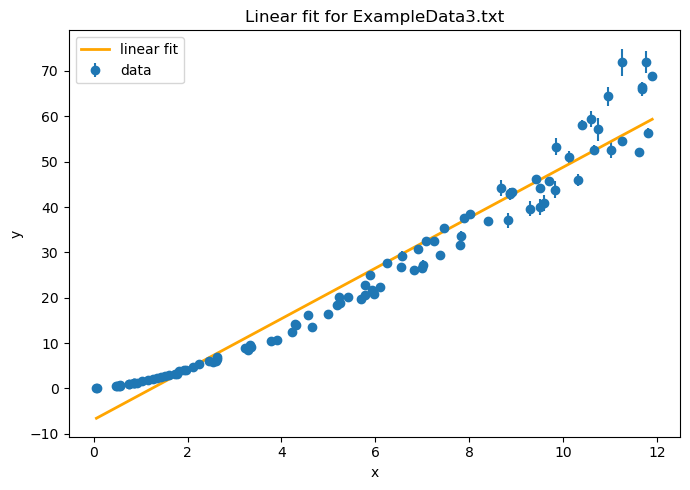

In [197]:
# 3. Read in the file ”Basics/ExampleData3.dat”. Make a visually informative plot of these data

import numpy as np
import matplotlib.pyplot as plt

# load data (skip header, unpack X, Y, YErrors)
x, y, yerr = np.loadtxt("ExampleData3.txt", skiprows=1, unpack=True)

# compute best-fit slope, intercept, and R^2 using previous linear_fit function
a, b, R2 = linear_fit(x, y)

# generate x-values and corresponding model y-values for plotting the fit line
xs = np.linspace(x.min(), x.max(), 300)
ys = a * xs + b

print("Results for ExampleData3.txt:")
print("  alpha (slope)     =", a)
print("  beta  (intercept) =", b)
print("  R^2               =", R2)

# plot
plt.figure(figsize=(7,5))
plt.errorbar(x, y, yerr=yerr, fmt='o', label="data")
plt.plot(xs, ys, color="orange", linewidth=2, label="linear fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear fit for ExampleData3.txt")
plt.legend()
plt.tight_layout()
plt.show()

# The data in ExampleData3.txt show a nonlinear trend, even though they increase overall. The linear fits
# the general upward slope and gives a fairly high R^2 value, but the plot shows a clear curve that the best-fit
# line doesn't follow. So, the model gives an approximation but isn't a very accurate predictor.

In [11]:
# 4. This seems to be problematic, since the formalism of linear regression cannot be used to fit such a model. Briefly comment on why this is. If you take the logarithm of Equation 23, what relation emerges?

# A power-law model is not a straight-line equation, so it doesn't match the form that linear regression is designed to
# handle. Linear regression only works when the model can be written as a constant times a function plus another constant,
# but a power-law has the variable raised to a power, which makes it nonlinear. Because of this, we can't directly plug it
# into the usual least-squares formulas. The equation needs to be transformed before linear regression can be used.

# Starting with y = αx^β + y, if y=0 (or just assume its small enough to ignore), we get: y = ax^B. Taking the log of
# both sides: lny = lnα + βlnx. This is linear, a straight line and can be fit using standard linear regression but on
# log-transformed data.

Power-law fit parameters:
   α = 1.4624569743458766
   β = 1.53136428107094
   γ = 0
   R^2 (log-linear) = 0.9980567203223191


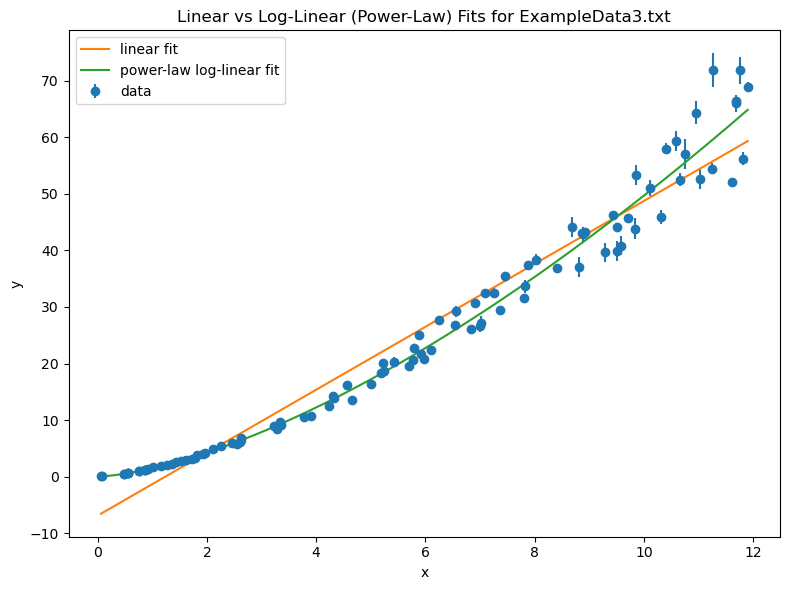

In [199]:
# 5. Take the logarithm of the x and y values, fit a linear relation to these data, calculate the best-fit values of α, β, γ. Make a plot of the data, the linear fit, and the log-linear fit.

# load data (3 columns: x, y, yerr)
x, y, yerr = np.loadtxt("ExampleData3.txt", skiprows=1, unpack=True)

# take logs (only valid if y > 0)
logx = np.log(x)
logy = np.log(y)

#fit log-linear model: ln(y) = ln(a) + B ln(x)
a_log, b_log, R2_log = linear_fit(logx, logy)   # slope = B, intercept = ln(a)

beta = a_log                     # slope
alpha = np.exp(b_log)            # intercept back-transformed
gamma = 0                        # must be assumed for log transform

print("Power-law fit parameters:")
print("   α =", alpha)
print("   β =", beta)
print("   γ =", gamma)
print("   R^2 (log-linear) =", R2_log)

# create prediction curves
xs = np.linspace(x.min(), x.max(), 300)

# linear straight-line fit
a_lin, b_lin, _ = linear_fit(x, y)
ys_lin = a_lin * xs + b_lin

# power-law curve y = a x^B
ys_power = alpha * xs**beta

# plot
plt.figure(figsize=(8,6))
plt.errorbar(x, y, yerr=yerr, fmt='o', label="data")

plt.plot(xs, ys_lin, label="linear fit")
plt.plot(xs, ys_power, label="power-law log-linear fit")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear vs Log-Linear (Power-Law) Fits for ExampleData3.txt")
plt.legend()
plt.tight_layout()
plt.show()

Log-linear power-law (γ = 0):
   α_log = 1.4624569743458766
   β_log = 1.53136428107094
   γ_log = 0.0

Nonlinear power-law fit:
   α_nl = 1.4624569743458766
   β_nl = 1.53136428107094
   γ_nl = 0.0


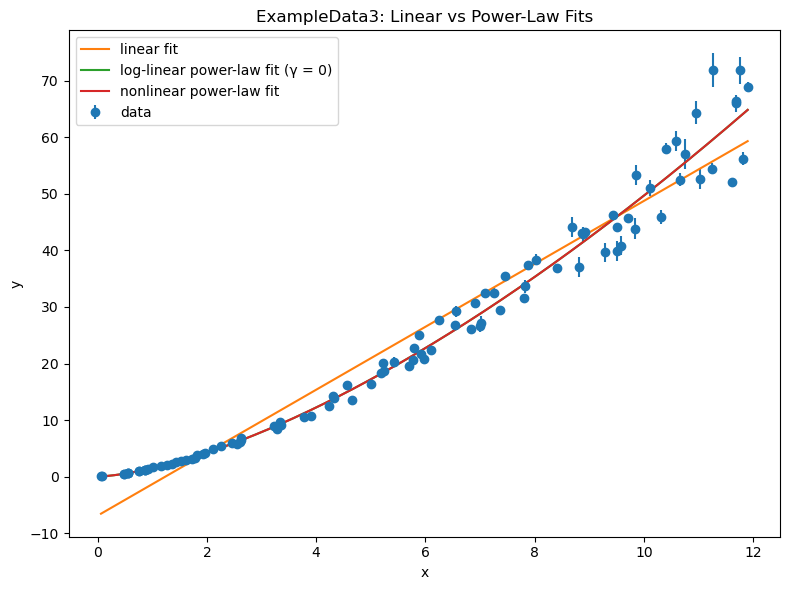

In [209]:
# 6. Find one of these that is NOT scipy.odr, and fit the data in ExampleData3.dat with it. Compare your best fit parameters with the log-linear fit results from above. Plt this fitted relation on the same figure as the linear and log-linear fits.
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html
# https://en.wikipedia.org/wiki/Non-linear_least_squares
# https://hernandis.me/2020/04/05/three-examples-of-nonlinear-least-squares-fitting-in-python-with-scipy.html

from scipy.optimize import curve_fit

# model for the nonlinear fit (a full power-law w additive constant gamma)
def power_law_model(x, alpha, beta, gamma):
    """
    Description:
        Power-law model with an additive constant: y = α x^β + γ.

    Inputs:
        x (Independent variable)
        alpha (Amplitude of the power-law)
        beta (Exponent of the power-law)
        gamma (Additive constant offset)

    Outputs:
        y (Model values computed as α x^β + γ for the given x)
    """
    return alpha * x**beta + gamma

# load data from file
x, y, yerr = np.loadtxt("ExampleData3.txt", skiprows=1, unpack=True)

# perform a linear fit directly to x and y for comparison
a_lin, b_lin, R2_lin = linear_fit(x, y)
xs = np.linspace(x.min(), x.max(), 300)
ys_lin = a_lin * xs + b_lin

# transform x and y into log space and fit straight line to estimate alpha and beta
logx = np.log(x)
logy = np.log(y)
beta_log, ln_alpha_log, R2_log = linear_fit(logx, logy)
alpha_log = np.exp(ln_alpha_log)
gamma_log = 0.0
ys_power_log = alpha_log * xs**beta_log

# use nonlinear least-squares routine to fit full power-law model to original data
# initial parameter guesses come from the log-linear fit above
p0 = [alpha_log, beta_log, gamma_log]

popt, pcov = curve_fit(
    power_law_model,
    x,
    y,
    p0=p0,
    sigma=yerr,
    absolute_sigma=True
)

# extract nonlinear best-fit values and use to compute model curve
alpha_nl, beta_nl, gamma_nl = popt
ys_power_nl = power_law_model(xs, alpha_nl, beta_nl, gamma_nl)

print("Log-linear power-law (γ = 0):")
print("   α_log =", alpha_log)
print("   β_log =", beta_log)
print("   γ_log =", gamma_log)
print()
print("Nonlinear power-law fit:")
print("   α_nl =", alpha_nl)
print("   β_nl =", beta_nl)
print("   γ_nl =", gamma_nl)


# plot raw data and all three fitted curves
plt.figure(figsize=(8, 6))
plt.errorbar(x, y, yerr=yerr, fmt='o', label="data")
plt.plot(xs, ys_lin, label="linear fit")
plt.plot(xs, ys_power_log, label="log-linear power-law fit (γ = 0)")
plt.plot(xs, ys_power_nl, label="nonlinear power-law fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("ExampleData3: Linear vs Power-Law Fits")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# 7. Read in the file ”Basics/ExampleData4.dat”. Without plotting the data, fit a linear model to the data and inspect the goodness of fit it produces. Do the fit results alone suggest the linear model is a good one?

# load data
x4, y4, yerr4 = np.loadtxt("ExampleData4.txt", skiprows=1, unpack=True)

# fit linear model
a4, b4, R2_4 = linear_fit(x4, y4)

print("Linear fit for ExampleData4.txt:")
print("  slope (a)      =", a4)
print("  intercept (b)  =", b4)
print("  R^2            =", R2_4)


# Based on the results, the linear model seems to work very well. It results in an R^2 value of 0.998, which is extremly high. A slope
# of about 1.21 and a small intercept also show a stable fit. So yes, from the fit results alone, they suggest that the linear model
# is a good one.

Linear fit for ExampleData4.txt:
  slope (a)      = 1.2146024918205036
  intercept (b)  = -0.6304938845085815
  R^2            = 0.9976974917409317


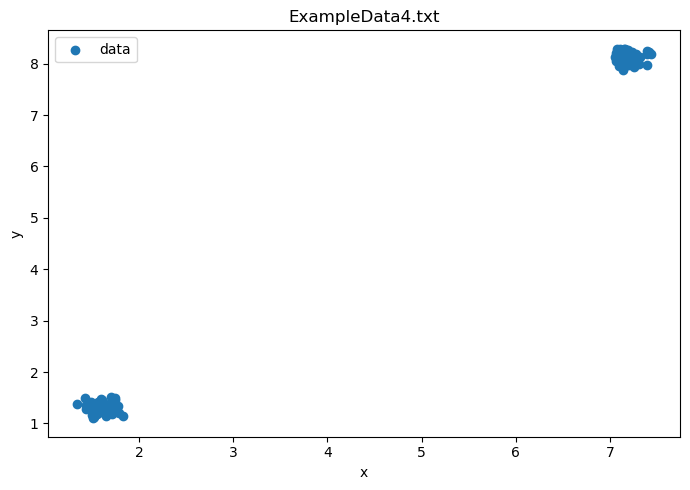

In [207]:
# 8. Now plot the data in ExampleData4.dat. By looking at the data, is a linear model appropriate? Give answers under the following two scenarios.

x, y, yerr = np.loadtxt("ExampleData4.txt", skiprows=1, unpack=True)

plt.figure(figsize=(7,5))
plt.scatter(x, y, label="data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("ExampleData4.txt")
plt.legend()
plt.tight_layout()
plt.show()

# Scenario 1: It seems that my lab assistant chose really narrow ranges of x, which is what likely produced the two
# tight clusters in the far corners. And so because the data cover only two tiny regions of the x-range, the linear
# regression can't actually see what is going on in those regions. The high R^2 value is misleading since it
# essentially is just connecting the two clusters with a line. I think I could not reliably say that the underlying
# relationship is linear since the sampling is too limited. I would say to my assistant "Next time, please sample x
# values across the full range, not just two small clusters. Otherwise we can't tell whether it behaves linearly or
# not.

# Scenario 2: Here the objects are naturally distributed, and both x and y are measured quantities. This makes the
# two-cluster pattern real. Still, the high R^2 value is misleading. I can easily conclude in this scenario that a
# linear model is not good for this data. A single straight loine connected two separate clouds of points does not
# represent a real physical rekationship. Instead, I'd probably suggest modeling them separately.

In [29]:
# 9. In one of the cases above, a linear model is not appropriate. What sort of model might be?
# https://en.wikipedia.org/wiki/Model-based_clustering?


# A clustering model like a two-component model or Gaussian mixture. This treats the points as belonging to two 
# different populations instead of trying to force one function to fit everything.

## 18.5 Fitting a standard stellar spectrum

In [211]:
# 1. Write a function that takes as input a single temperature and an array of wavelengths, and outputs a blackbody curve. Use SI units.
# https://en.wikipedia.org/wiki/Planck%27s_law

import numpy as np

# physical constants in SI units
h = 6.62607015e-34      # planck's constant [J s]
c = 2.99792458e8        # speed of light [m/s]
k_B = 1.380649e-23        # Boltzmann constant [J/K]

def blackbody(T, lam):
    """
    Description:
        Calculates the blackbody curve for a given temperature.
        You give it one temperature and an array of wavelengths,
        and it returns the brightness of a perfect blackbody at
        each wavelength. All units are in SI.

    Inputs:
        T (temperature in Kelvin)
        lam (wavelengths in meters)

    Outputs:
        B_lambda (blackbody intensity at each wavelength (W·m⁻²·sr⁻¹·m⁻¹))
    """
    lam = np.asarray(lam)  # ensure array
    a = 2.0 * h * c**2 / lam**5  #planck's law in wv form
    b = h * c / (lam * k_B * T)  #^
    return a / (np.exp(b) - 1.0)

/var/folders/tx/xp0lqmxx3xl6fl1m1t16qqdc0000gn/T/ipykernel_57074/3051510142.py:28: RuntimeWarning: overflow encountered in exp
  return a / (np.exp(b) - 1.0)


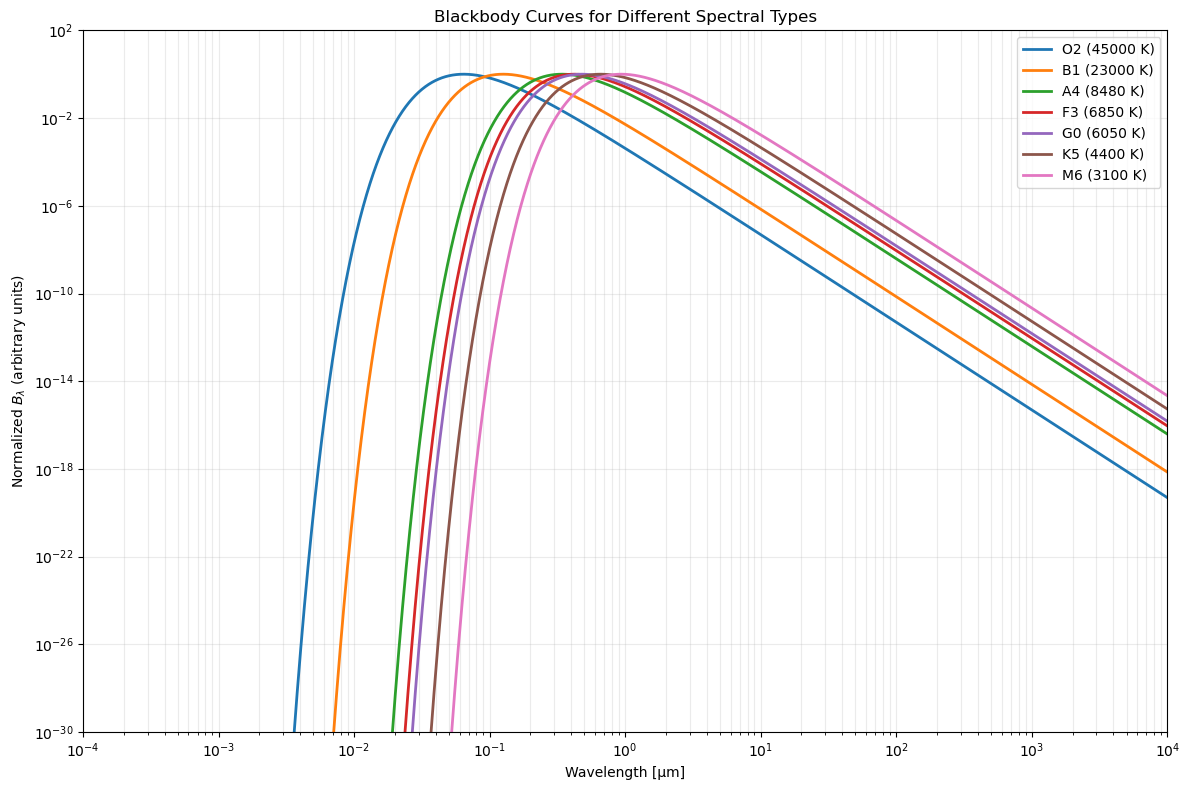

Spectral Type   Temperature (K)
-------------------------------
O2              45000
B1              23000
A4               8480
F3               6850
G0               6050
K5               4400
M6               3100


In [225]:
# 2. Use this function to generate seven pure blackbody curves, for temperatures corresponding to the following stars: O2, B1, A4, F3, G0, K5, M6.
#https://sites.uni.edu/morgans/astro/course/Notes/section2/spectraltemps.html

import numpy as np
import matplotlib.pyplot as plt

spectral_types = {
    "O2": 45000,
    "B1": 23000,
    "A4": 8480,
    "F3": 6850,
    "G0": 6050,
    "K5": 4400,
    "M6": 3100,
}

# wv range
lam_m = np.logspace(-10, -2, 6000)
lam_um = lam_m * 1e6

plt.figure(figsize=(12, 8))

for sp, T in spectral_types.items():
    B = blackbody(T, lam_m)
    B_norm = B / np.max(B)
    plt.plot(lam_um, B_norm, label=f"{sp} ({T} K)", linewidth=2)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Wavelength [µm]")
plt.ylabel("Normalized $B_\\lambda$ (arbitrary units)")
plt.title("Blackbody Curves for Different Spectral Types")

# view window
plt.xlim(1e-4, 1e4)
plt.ylim(1e-30, 1e2)

plt.legend(loc="upper right", fontsize=10)
plt.grid(alpha=0.25, which="both")
plt.tight_layout()
plt.show()


# print table
print("Spectral Type   Temperature (K)")
print("-------------------------------")
for sp, T in spectral_types.items():
    print(f"{sp:10s}   {T:>8d}")

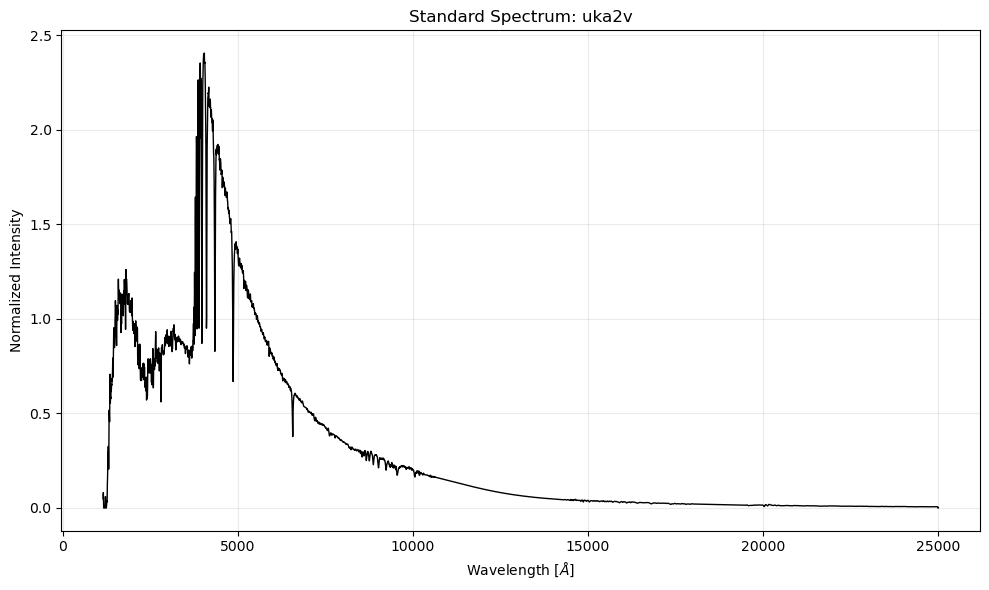

In [21]:
# 3. Pick one of these spectra, read it in, and make a plot of the spectrum.

#with open("uka2v.dat", "r") as f:
#    for i in range(20):
#        print(f.readline().rstrip())

import numpy as np
import matplotlib.pyplot as plt

# load columns from file
data = np.loadtxt("StandardSpectra/uka2v.dat", comments="#")

# extract wavelength (col 0) and flux (col 1 = 'lk')
wave_A = data[:, 0]
flux_norm = data[:, 1]   # you can change to 2 or 3 if desired

# plot
plt.figure(figsize=(10, 6))
plt.plot(wave_A, flux_norm, color="black", linewidth=1)

plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel("Normalized Intensity")
plt.title("Standard Spectrum: uka2v")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

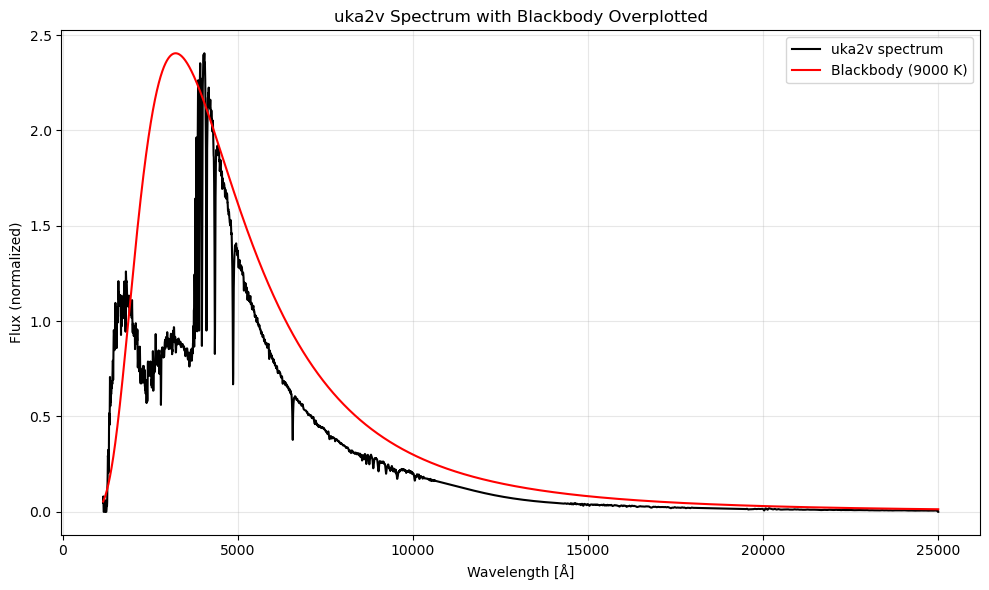

In [227]:
# 4. Generate and overplot a blackbody curve with the same temperature (as in- ferred by spectral type) as your chosen star, adjusting the normalization as necessary.

T = 9000  # temp inferred from spectral type (A2)

# convert wavelength Å → m
lam_m = wave_A * 1e-10

# compute blackbody
bb = blackbody(T, lam_m)

# scale blackbody so its peak matches the observed spectrum (for shape comparison)
scale = flux_norm.max() / bb.max()
bb_scaled = bb * scale

#plot observed spectrum + blackbody
plt.figure(figsize=(10,6))
plt.plot(wave_A, flux_norm, label="uka2v spectrum", color="black")
plt.plot(wave_A, bb_scaled, label=f"Blackbody ({T} K)", color="red")

plt.xlabel("Wavelength [Å]")
plt.ylabel("Flux (normalized)")
plt.title("uka2v Spectrum with Blackbody Overplotted")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# The observed spectrum and the blackbody curve have the same overall shape, but the real spectrum shows a lot of 
# absorption features that the blackbody does not. At longer wavelengths, where the spectrum has less lines, the
# continuum follows the blackbody a lot closer. Overall, a good shape match I'd say, though the peak is slightly off.

Best-fit temperature: 7889.73258357308 K
Uncertainty: 144.3227296963965 K


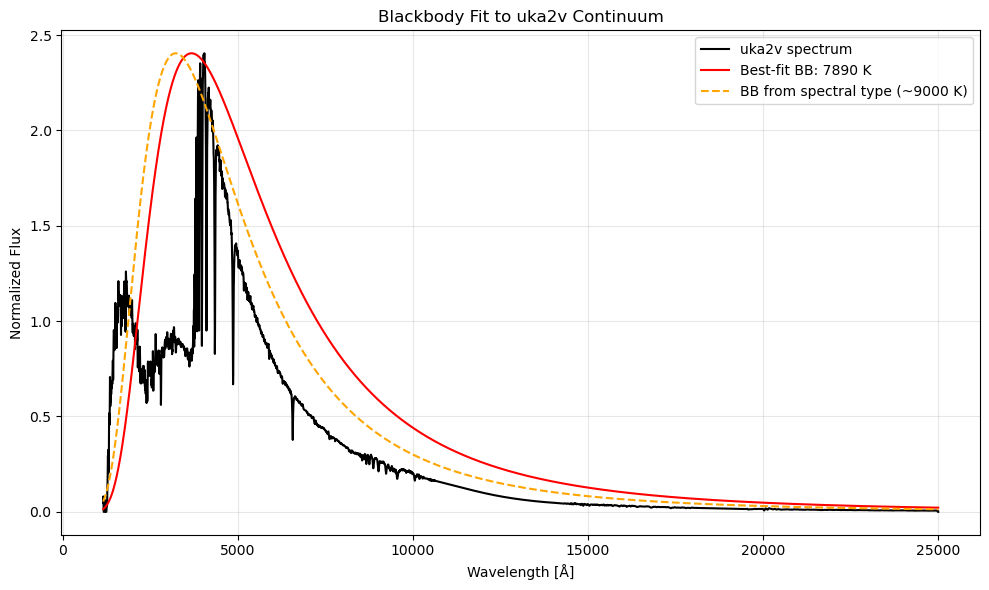

In [231]:
# 5. Using a python approach of your choice (which you should describe), fit a blackbody function to your chosen stellar spectrum, and derive the best fit temperature and uncertainty.
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# blackbody model for fitting
# F(λ) = A * B_λ(T)
# curve_fit will vary T and A to minimize squared residuals
def bb_model(lam_A, T, A):
    """
    Description:
        Takes wavelengths in Angstroms, converts them to meters,
        evaluates the blackbody function at temperature T,
        and scales the result by A.

    Inputs:
        lam_A (array of wavelengths)
        T (temp in Kelvin)
        A (amplitude scaling factor)

    Outputs:
        array of scaled blackbody flux values
    """
    lam_m = lam_A * 1e-10        # convert Å → meters for the blackbody function
    return A * blackbody(T, lam_m)

# choose continuum points
# avoid λ < 3500 Å and avoid λ > 9000 Å
mask = (wave_A > 3500) & (wave_A < 9000) & (flux_norm > 0.6)  # keep only flux > 0.6 to avoid deep absorption lines

# wavelength and flux arrays we will fit to
lam_cont  = wave_A[mask]
flux_cont = flux_norm[mask]

# fit the blackbody model
# curve_fit performs non-linear least squares, return best-fit parameters and covariance matrix
popt, pcov = curve_fit(bb_model, lam_cont, flux_cont, p0=[7200, 1.0])

T_fit, A_fit = popt                 # extract fitted temperature + scale
T_err = np.sqrt(np.diag(pcov))[0]    # 1σ uncertainty from covariance

print("Best-fit temperature:", T_fit, "K")
print("Uncertainty:", T_err, "K")

# compute best-fit curve
bb_fit_raw = bb_model(wave_A, T_fit, A_fit)

# rescale the fitted curve for plotting only
# the continuum envelope peak (like the 7200 K reference curve)
scale_fit = flux_norm.max() / bb_model(wave_A, T_fit, 1).max()
bb_fit = bb_model(wave_A, T_fit, scale_fit)

T_spectral = 9000  # A2 star
scale_spec = flux_norm.max() / bb_model(wave_A, T_spectral, 1).max()
bb_spec = bb_model(wave_A, T_spectral, scale_spec)

# plot data + best-fit + comparison curve
plt.figure(figsize=(10, 6))
plt.plot(wave_A, flux_norm, color="black", label="uka2v spectrum")

# best-fit temperature (red curve)
plt.plot(wave_A, bb_fit, color="red",
         label=f"Best-fit BB: {T_fit:.0f} K")

#spectral type blackbody curve
plt.plot(wave_A, bb_spec, color="orange", linestyle="--",
         label=f"BB from spectral type (~{T_spectral} K)")

plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized Flux")
plt.title("Blackbody Fit to uka2v Continuum")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# The spectral type blackbody (A2=9000K) peaks too far and kinda sits above the observed continuum,
# while the fitted blackbody matches the continuum a bit better. This suggests that the quoted spectral type is roughly correct
# but too hot.

# I fit a model F(lambda) = AB(T) to continuum points using curve_fit. This does non-linear least-squares minimization. The
# algorithm adjusts T to A. This minimizes the squared difference between the model and the selected data. The best fit temp comes
# from the returned parameters and the uncertainty is taken from the square root of the covariance matrix.


File: StandardSpectra/ukb8v.dat
Best-fit temperature: 9411.133339610678 K
Uncertainty: 180.94395435181048 K


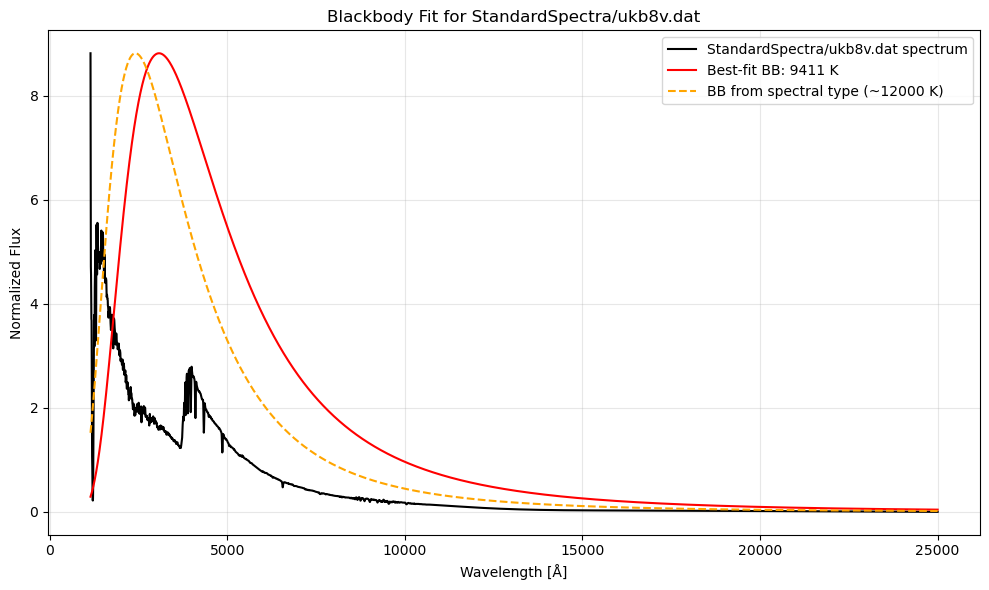


File: StandardSpectra/ukb9v.dat
Best-fit temperature: 8821.265097768975 K
Uncertainty: 154.604165028015 K


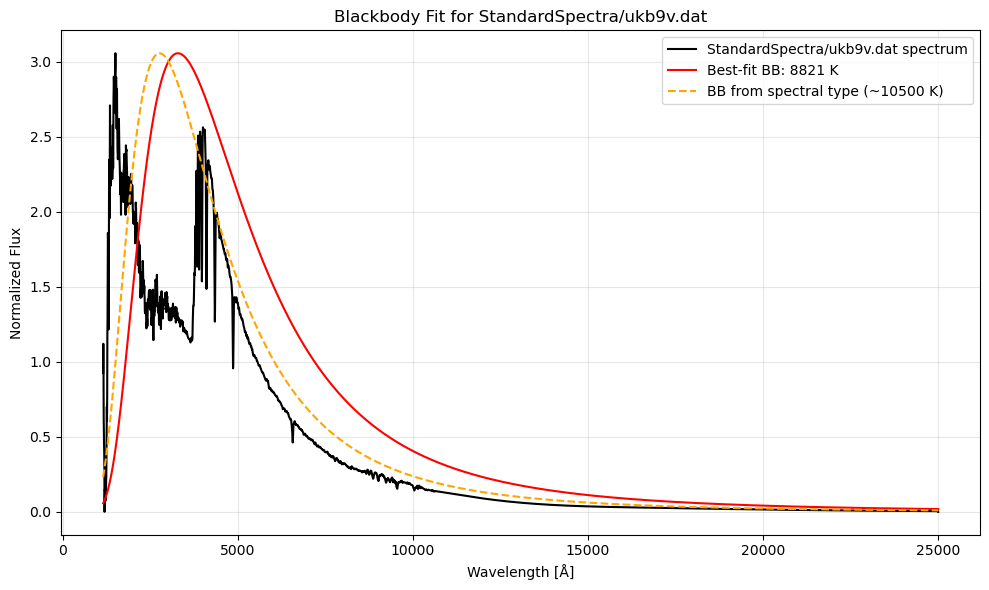


File: StandardSpectra/ukf0v.dat
Best-fit temperature: 6885.3361261261 K
Uncertainty: 54.71506097705903 K


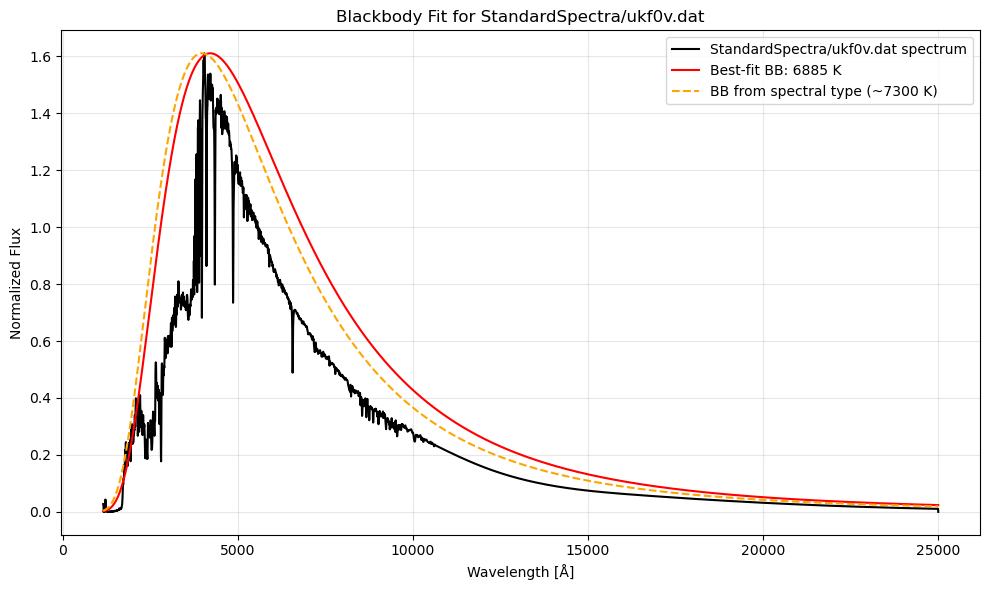


File: StandardSpectra/ukf5v.dat
Best-fit temperature: 6441.7101097029445 K
Uncertainty: 27.217294522723833 K


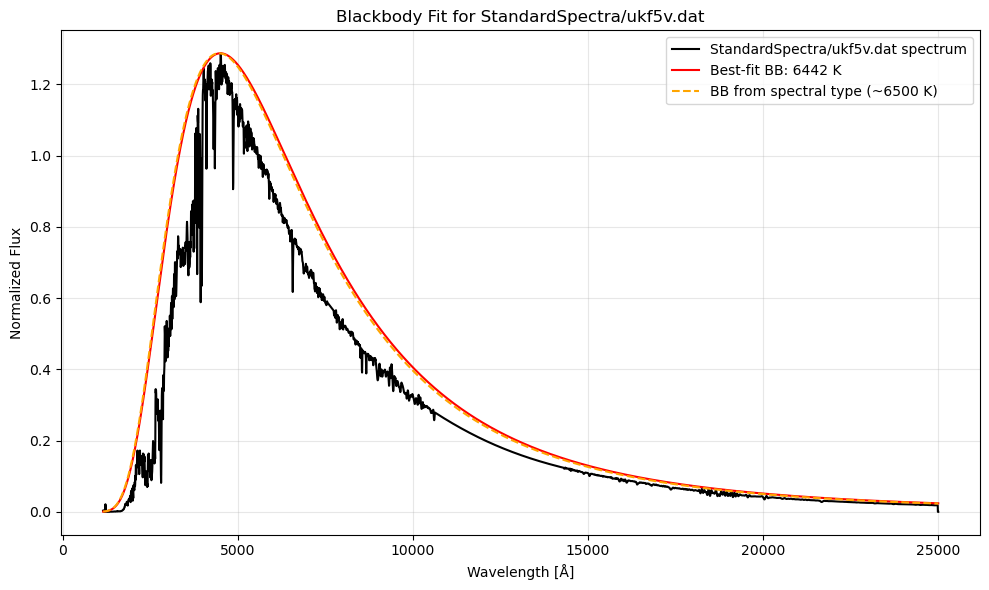


File: StandardSpectra/ukm2v.dat
Best-fit temperature: 3077.6968119084804 K
Uncertainty: 10.62658133692378 K


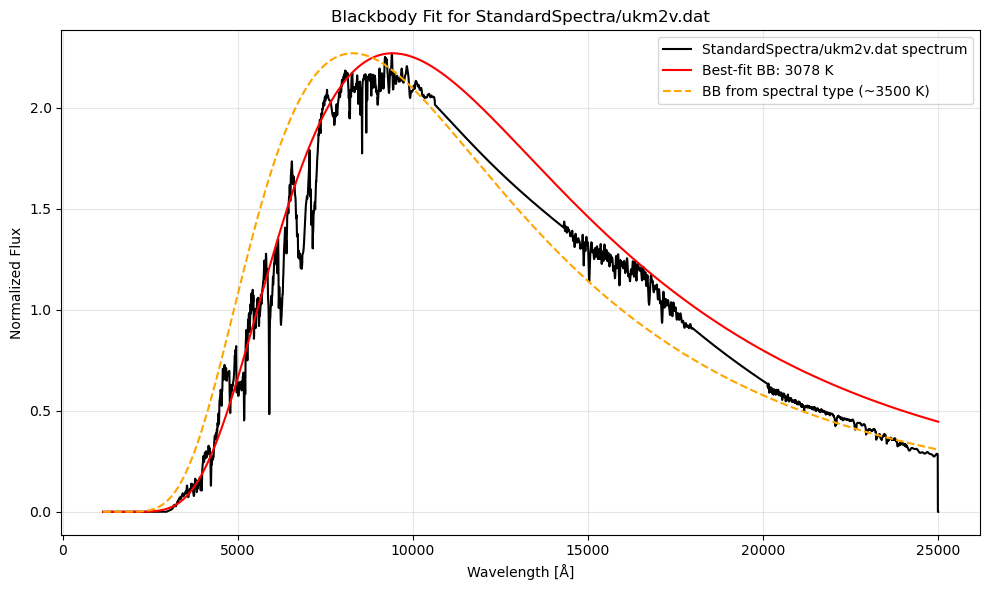

In [27]:
# 6. Repeat the above analysis steps for five further standard spectra, of your choice.
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html

def fit_and_plot_spectrum(filename, T_spectral):
    """
    Description:
        Loads a stellar spectrum, selects continuum regions,
        fits a blackbody curve to those regions, and overplots: the 
        observed spectrum, the best-fit blackbody, a blackbody using 
        the catalog (spectral-type) temperature

    Inputs:
        filename (name of the .dat file containing wavelength + flux)
        T_spectral (expected temperature based on spectral type)

    Outputs:
        T_fit (best-fit temperature from curve_fit)
        T_err (1-sigma uncertainty on T_fit)
    """

    # load wavelength (Å) and normalized flux
    data = np.loadtxt(filename, comments="#")
    wave_A = data[:, 0]
    flux_norm = data[:, 1]

    # continuum mask: avoid blue/red edges + avoid absorption dips
    mask = (wave_A > 3500) & (wave_A < 9000) & (flux_norm > 0.6)
    lam_cont  = wave_A[mask]        # continuum wavelengths
    flux_cont = flux_norm[mask]     # continuum flux values

    # fit F(λ) = A * B_λ(T) using nonlinear least-squares
    popt, pcov = curve_fit(
        bb_model,             # model function
        lam_cont,              # wavelengths used in fit
        flux_cont,             # corresponding fluxes
        p0=[T_spectral, 1.0]   # initial guess to help convergence
    )

    T_fit, A_fit = popt   # best-fit temp + amp
    T_err = np.sqrt(np.diag(pcov))[0]   # uncertainty on temp

    print(f"\nFile: {filename}")
    print("Best-fit temperature:", T_fit, "K")
    print("Uncertainty:", T_err, "K")

    # scale best-fit BB so its peak matches the observed peak (makes comparison clearer)
    scale_fit = flux_norm.max() / bb_model(wave_A, T_fit, 1).max()
    bb_fit = bb_model(wave_A, T_fit, scale_fit)

    # scale blackbody predicted by the spectral type
    scale_spec = flux_norm.max() / bb_model(wave_A, T_spectral, 1).max()
    bb_spec = bb_model(wave_A, T_spectral, scale_spec)

    # plotting
    plt.figure(figsize=(10, 6))
    plt.plot(wave_A, flux_norm, color="black", label=f"{filename} spectrum") # observed spectrum
    plt.plot(wave_A, bb_fit, color="red", label=f"Best-fit BB: {T_fit:.0f} K") # fitted curve
    plt.plot(wave_A, bb_spec, color="orange", linestyle="--", label=f"BB from spectral type (~{T_spectral} K)") # spectral-type curve

    plt.xlabel("Wavelength [Å]")
    plt.ylabel("Normalized Flux")
    plt.title(f"Blackbody Fit for {filename}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return T_fit, T_err


# mapping between file names and spectral-type temperatures (ish)
spectral_temps = {
    "StandardSpectra/ukb8v.dat": 12000,
    "StandardSpectra/ukb9v.dat": 10500,
    "StandardSpectra/ukf0v.dat": 7300,
    "StandardSpectra/ukf5v.dat": 6500,
    "StandardSpectra/ukm2v.dat": 3500,
}

# run the analysis for 5 stars
for fname, Tspec in spectral_temps.items():
    fit_and_plot_spectrum(fname, Tspec)

## 18.6 Fitting unknown stellar spectra

### 18.6.1

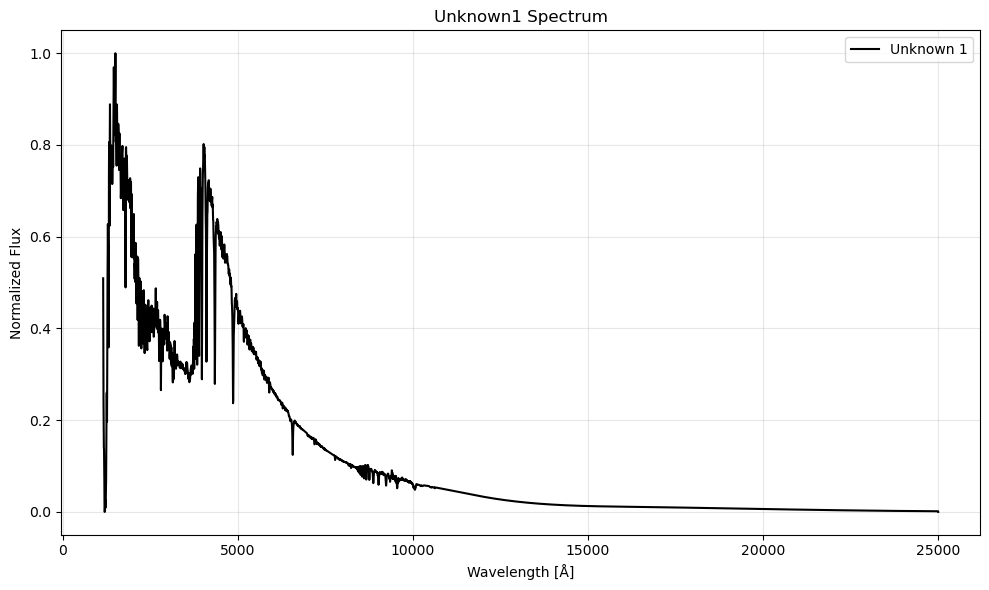

In [233]:
# 1. Choose one of these spectra and read it in. Then find the two that are closest to it. Generate a plot of the unknown with these two standards overplotted.

import numpy as np
import matplotlib.pyplot as plt

def load_unknown(filename):
    """
    Load an unknown spectrum (6-column format).

    Inputs:
        filename (string): e.g. "unknown1.dat"

    Outputs:
        wave_A : array of wavelengths (Å)
        flux   : array of flux values (we use column 1)
    """
    data = np.loadtxt(filename, comments="#")
    wave_A = data[:, 0]   # wavelength
    flux   = data[:, 1]   # use column 1 as the flux
    return wave_A, flux

def load_standard(filename):
    """
    Load a standard spectrum (2-column format).

    Inputs:
        filename (string): e.g. "uka7v.dat"

    Outputs:
        wave_A : array of wavelengths (Å)
        flux   : array of normalized flux values
    """
    data = np.loadtxt(filename, comments="#")
    wave_A = data[:, 0]   # extract wavelength column (in Angstroms)
    flux   = data[:, 1]   # extract corresponding flux values
    return wave_A, flux

# load the wavelength and flux arrays for first unknown spectrum
unk_wave1, unk_flux1 = load_unknown("UnknownSpectra/unknown1")

plt.figure(figsize=(10,6))
plt.plot(unk_wave1, unk_flux1 / unk_flux1.max(), color="black", label="Unknown 1")
plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized Flux")
plt.title("Unknown1 Spectrum")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

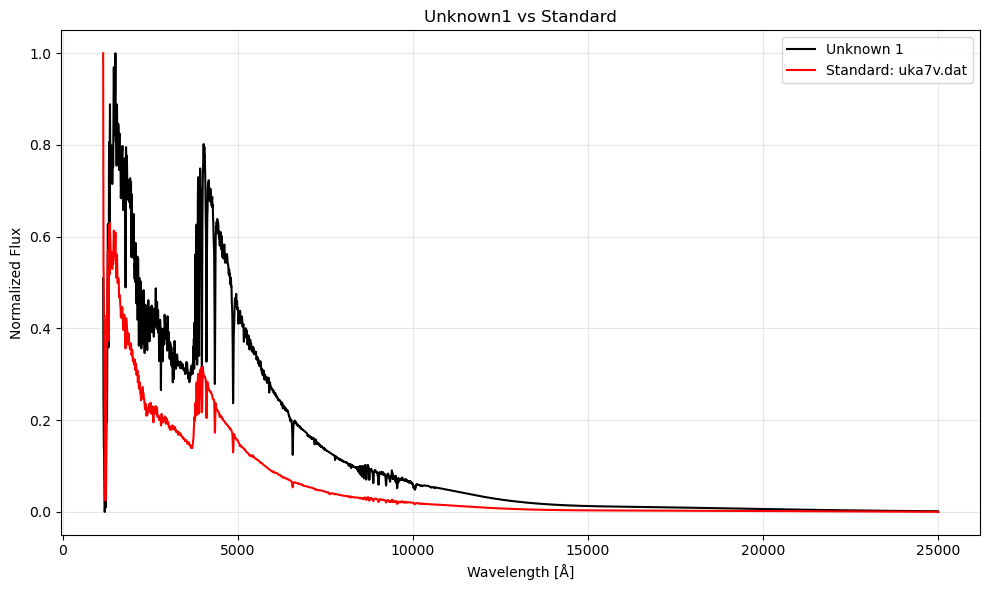

In [31]:
std_wave1, std_flux1 = load_standard("StandardSpectra/ukb8v.dat")  # change to the standard you want

# normalize both so we only compare shape, not absolute flux
unk_norm1  = unk_flux1 / unk_flux1.max()
std_norm1  = std_flux1 / std_flux1.max()

plt.figure(figsize=(10,6))
plt.plot(unk_wave1, unk_norm1, color="black", label="Unknown 1")
plt.plot(std_wave1, std_norm1, color="red", label="Standard: uka7v.dat")

plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized Flux")
plt.title("Unknown1 vs Standard")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

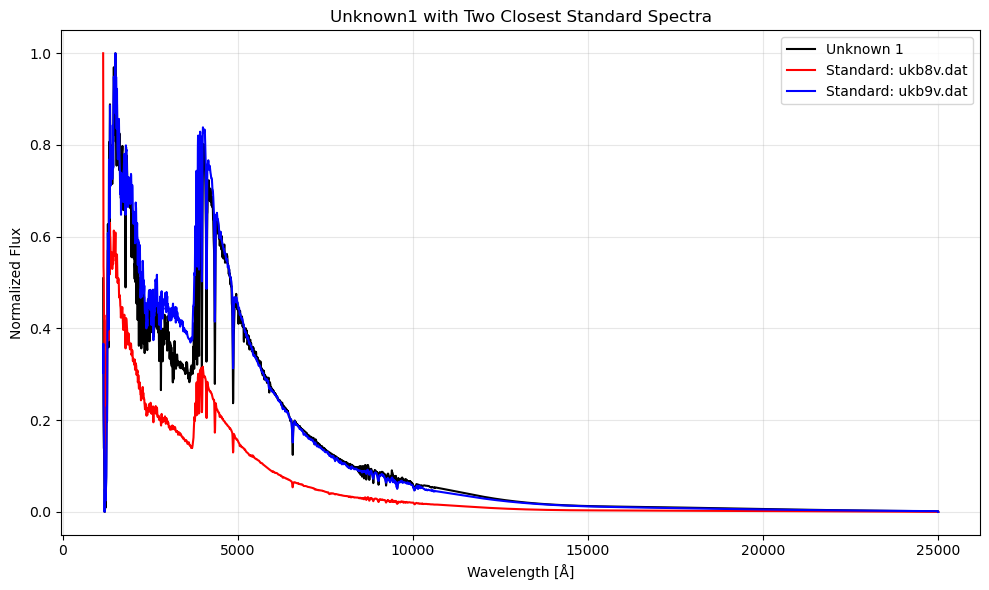

In [33]:
# unknown (we already loaded unk_wave, unk_flux)
unk_norm1 = unk_flux1 / unk_flux1.max()

# load the two closest standards
std1_wave1, std1_flux1 = load_standard("StandardSpectra/ukb8v.dat")  # closest match #1
std2_wave1, std2_flux1 = load_standard("StandardSpectra/ukb9v.dat")  # closest match #2

std1_norm1 = std1_flux1 / std1_flux1.max()
std2_norm1 = std2_flux1 / std2_flux1.max()

plt.figure(figsize=(10,6))
plt.plot(unk_wave1,  unk_norm1,  color="black", label="Unknown 1")
plt.plot(std1_wave1, std1_norm1, color="red",   label="Standard: ukb8v.dat")
plt.plot(std2_wave1, std2_norm1, color="blue",  label="Standard: ukb9v.dat")

plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized Flux")
plt.title("Unknown1 with Two Closest Standard Spectra")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 18.6.2

Best-fit temperature: 12201.427727834269 K
Uncertainty: 119.14517459493477 K


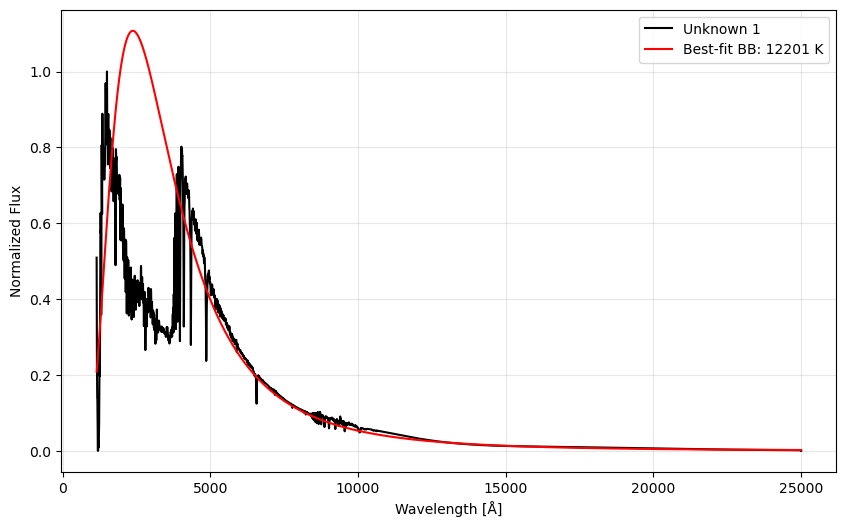

In [35]:
# 2. Fit a blackbody curve to your unknown spectrum. Obtain the best-fit temperature and the uncertainty on this value.

# load unknown spectrum
wave1, flux1 = load_unknown("UnknownSpectra/unknown1")

# normalize flux
flux_norm1 = flux1 / flux1.max()

# pick only continuum-like points using simple mask
mask1 = flux_norm1 > 0.6
lam_cont1  = wave1[mask1]
flux_cont1 = flux_norm1[mask1]

# fit the blackbody model
popt1, pcov1 = curve_fit(bb_model, lam_cont1, flux_cont1, p0=[11000, 1])
T_fit1, A_fit1 = popt1
T_err1 = np.sqrt(np.diag(pcov1))[0]

print("Best-fit temperature:", T_fit1, "K")
print("Uncertainty:", T_err1, "K")

# compute best-fit curve for plotting
bb_fit1 = bb_model(wave1, T_fit1, A_fit1)

# Plot
plt.figure(figsize=(10,6))
plt.plot(wave1, flux_norm1, color="black", label="Unknown 1")
plt.plot(wave1, bb_fit1,   color="red",   label=f"Best-fit BB: {T_fit1:.0f} K")
plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized Flux")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 18.6.3 #1 (do the same to 3 other unknown spectra)

In [37]:
unk_wave2, unk_flux2 = load_unknown("UnknownSpectra/unknown2")

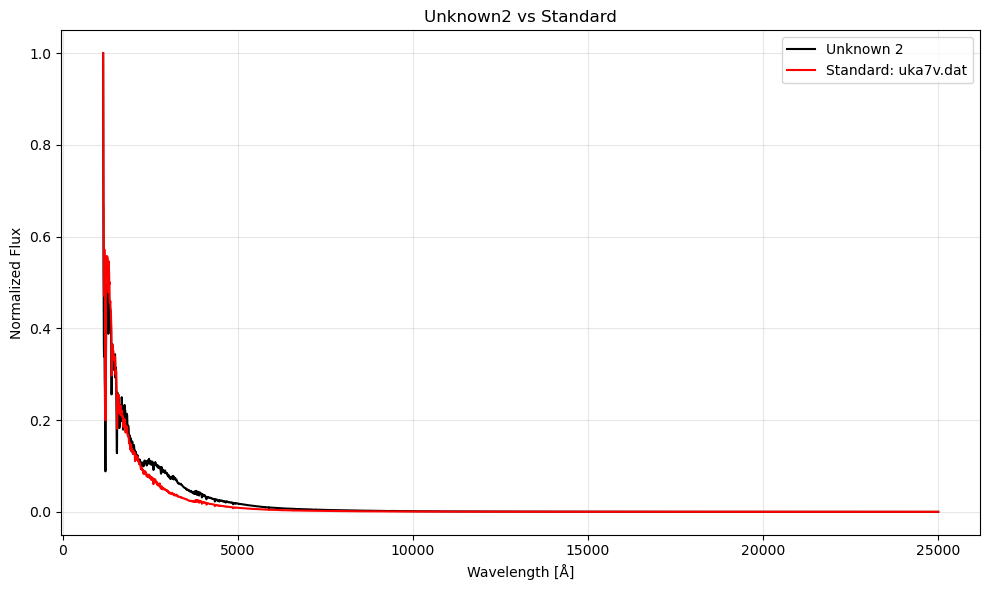

In [39]:
# this block is to find the 2 closest spectra

std_wave2, std_flux2 = load_standard("StandardSpectra/ukb0v.dat")  # change to the standard you want

# normalize both so we only compare shape, not absolute flux
unk_norm2  = unk_flux2 / unk_flux2.max()
std_norm2  = std_flux2 / std_flux2.max()

plt.figure(figsize=(10,6))
plt.plot(unk_wave2, unk_norm2, color="black", label="Unknown 2")
plt.plot(std_wave2, std_norm2, color="red", label="Standard: uka7v.dat")

plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized Flux")
plt.title("Unknown2 vs Standard")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

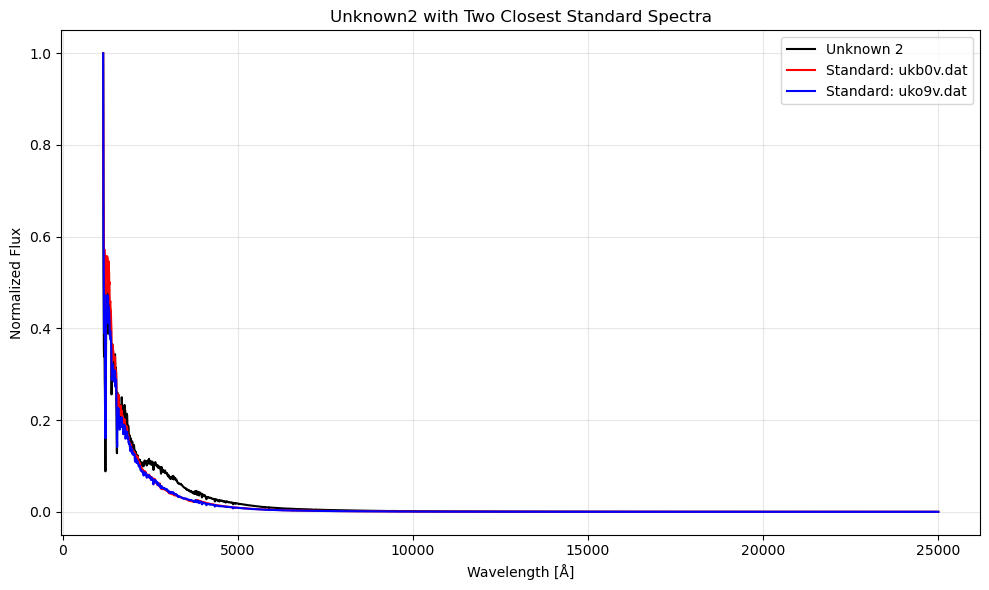

In [41]:
# this block is to plot uknown 2 with the two closest standard spectra

# unknown (we already loaded unk_wave, unk_flux)
unk_norm2 = unk_flux2 / unk_flux2.max()

# load the two closest standards
std1_wave2, std1_flux2 = load_standard("StandardSpectra/ukb0v.dat")  # closest match #1
std2_wave2, std2_flux2 = load_standard("StandardSpectra/uko9v.dat")  # closest match #2

std1_norm2 = std1_flux2 / std1_flux2.max()
std2_norm2 = std2_flux2 / std2_flux2.max()

plt.figure(figsize=(10,6))
plt.plot(unk_wave2,  unk_norm2,  color="black", label="Unknown 2")
plt.plot(std1_wave2, std1_norm2, color="red",   label="Standard: ukb0v.dat")
plt.plot(std2_wave2, std2_norm2, color="blue",  label="Standard: uko9v.dat")

plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized Flux")
plt.title("Unknown2 with Two Closest Standard Spectra")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Best-fit temperature: 75495158.21778591 K
Uncertainty: 7626887624206.836 K


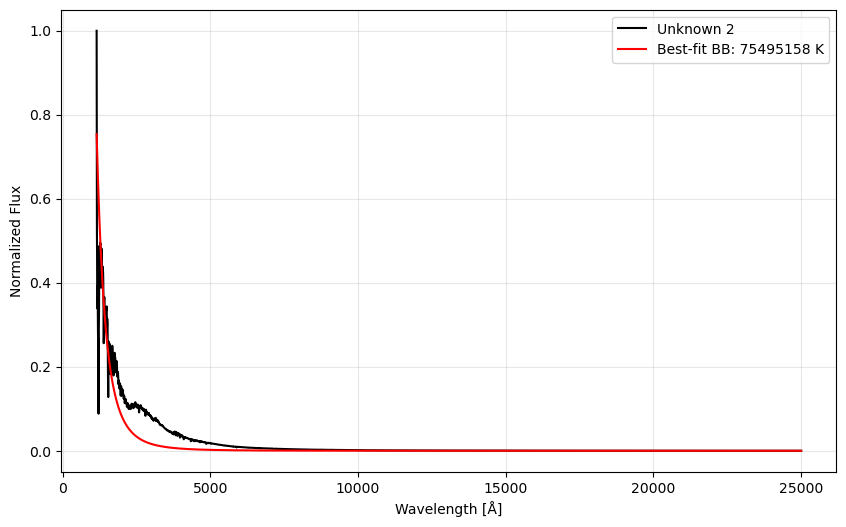

In [45]:
# this block is to plot the unknown and its best fit blackbody curve

# load unknown spectrum
wave2, flux2 = load_unknown("UnknownSpectra/unknown2")

# normalize flux
flux_norm2 = flux2 / flux2.max()

# pick only continuum-like points using simple mask
mask2 = flux_norm2 > 0.5
lam_cont2  = wave2[mask2]
flux_cont2 = flux_norm2[mask2]

# fit the blackbody model
popt2, pcov2 = curve_fit(bb_model, lam_cont2, flux_cont2, p0=[20000, 1], maxfev=2000)
T_fit2, A_fit2 = popt2
T_err2 = np.sqrt(np.diag(pcov2))[0]

print("Best-fit temperature:", T_fit2, "K")
print("Uncertainty:", T_err2, "K")

# compute best-fit curve for plotting
bb_fit2 = bb_model(wave2, T_fit2, A_fit2)

# plot
plt.figure(figsize=(10,6))
plt.plot(wave2, flux_norm2, color="black", label="Unknown 2")
plt.plot(wave2, bb_fit2,   color="red",   label=f"Best-fit BB: {T_fit2:.0f} K")
plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized Flux")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 18.6.3 #2

In [48]:
unk_wave3, unk_flux3 = load_unknown("UnknownSpectra/unknown3")

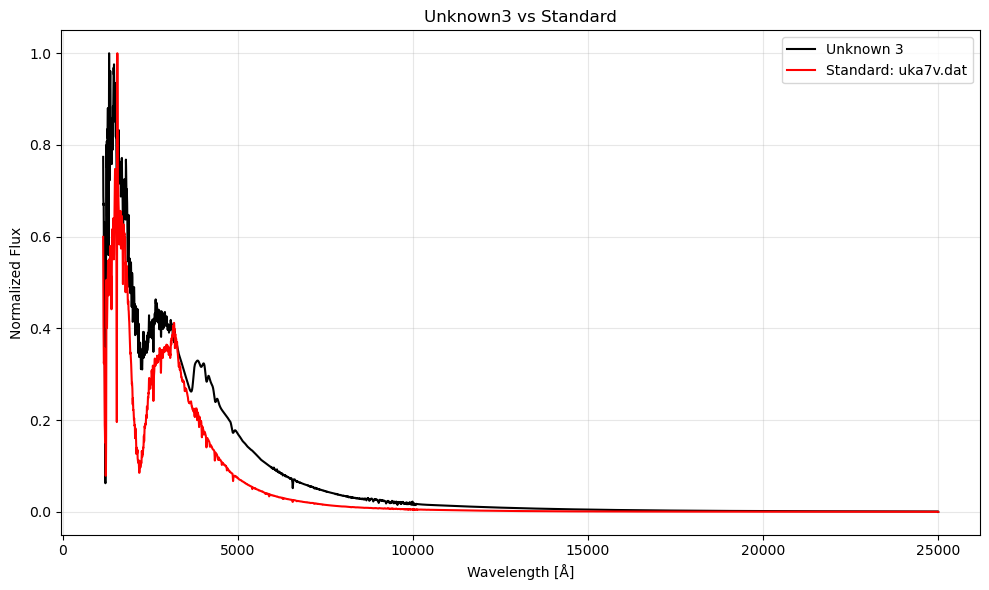

In [101]:
# this block is to find the 2 closest spectra

std_wave3, std_flux3 = load_standard("StandardSpectra/uko5v.dat")  # change to the standard you want

# normalize both so we only compare shape, not absolute flux
unk_norm3  = unk_flux3 / unk_flux3.max()
std_norm3  = std_flux3 / std_flux3.max()

plt.figure(figsize=(10,6))
plt.plot(unk_wave3, unk_norm3, color="black", label="Unknown 3")
plt.plot(std_wave3, std_norm3, color="red", label="Standard: uka7v.dat")

plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized Flux")
plt.title("Unknown3 vs Standard")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

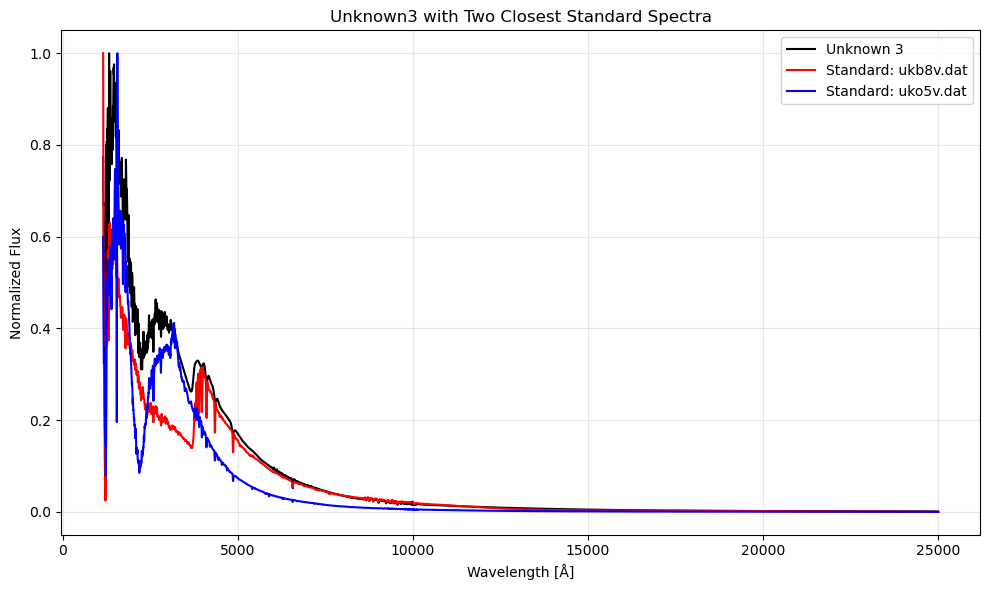

In [188]:
# this block is to plot uknown 3 with the two closest standard spectra

# unknown (we already loaded unk_wave, unk_flux)
unk_norm3 = unk_flux3 / unk_flux3.max()

# load the two closest standards
std1_wave3, std1_flux3 = load_standard("StandardSpectra/ukb8v.dat")  # closest match #1
std2_wave3, std2_flux3 = load_standard("StandardSpectra/uko5v.dat")  # closest match #2

std1_norm3 = std1_flux3 / std1_flux3.max()
std2_norm3 = std2_flux3 / std2_flux3.max()

plt.figure(figsize=(10,6))
plt.plot(unk_wave3,  unk_norm3,  color="black", label="Unknown 3")
plt.plot(std1_wave3, std1_norm3, color="red",   label="Standard: ukb8v.dat")
plt.plot(std2_wave3, std2_norm3, color="blue",  label="Standard: uko5v.dat")

plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized Flux")
plt.title("Unknown3 with Two Closest Standard Spectra")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Best-fit temperature: 20000.000011593103 K
Uncertainty: 1.5726329007515752e-05 K


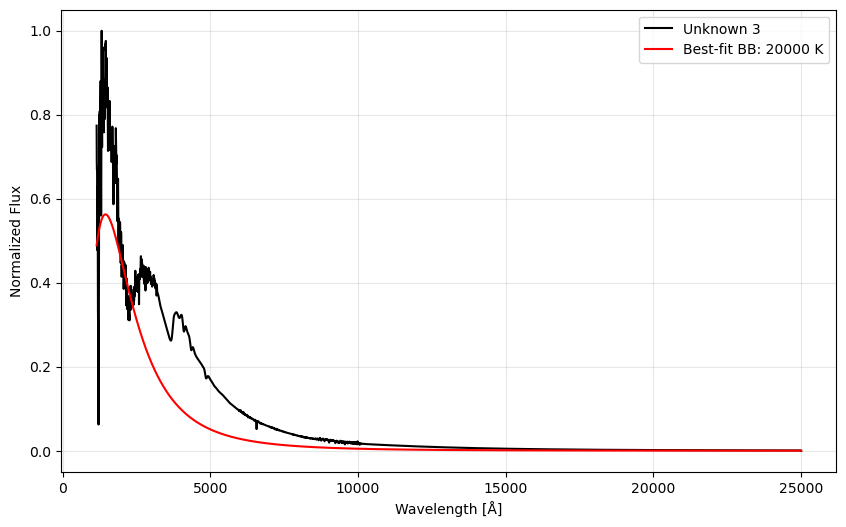

In [105]:
# this block is to plot the unknown and its best fit blackbody curve

# load unknown spectrum
wave3, flux3 = load_unknown("UnknownSpectra/unknown3")

# normalize flux
flux_norm3 = flux3 / flux3.max()

# pick only continuum-like points using simple mask
mask3 = flux_norm3 > 0.5
lam_cont3  = wave3[mask3]
flux_cont3 = flux_norm3[mask3]

# fit the blackbody model
popt3, pcov3 = curve_fit(bb_model, lam_cont3, flux_cont3, p0=[20000, 1], maxfev=2000)
T_fit3, A_fit3 = popt3
T_err3 = np.sqrt(np.diag(pcov3))[0]

print("Best-fit temperature:", T_fit3, "K")
print("Uncertainty:", T_err3, "K")

# compute best-fit curve for plotting
bb_fit3 = bb_model(wave3, T_fit3, A_fit3)

# plot
plt.figure(figsize=(10,6))
plt.plot(wave3, flux_norm3, color="black", label="Unknown 3")
plt.plot(wave3, bb_fit3,   color="red",   label=f"Best-fit BB: {T_fit3:.0f} K")
plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized Flux")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 18.6.3 #3

In [110]:
unk_wave4, unk_flux4 = load_unknown("UnknownSpectra/unknown4")

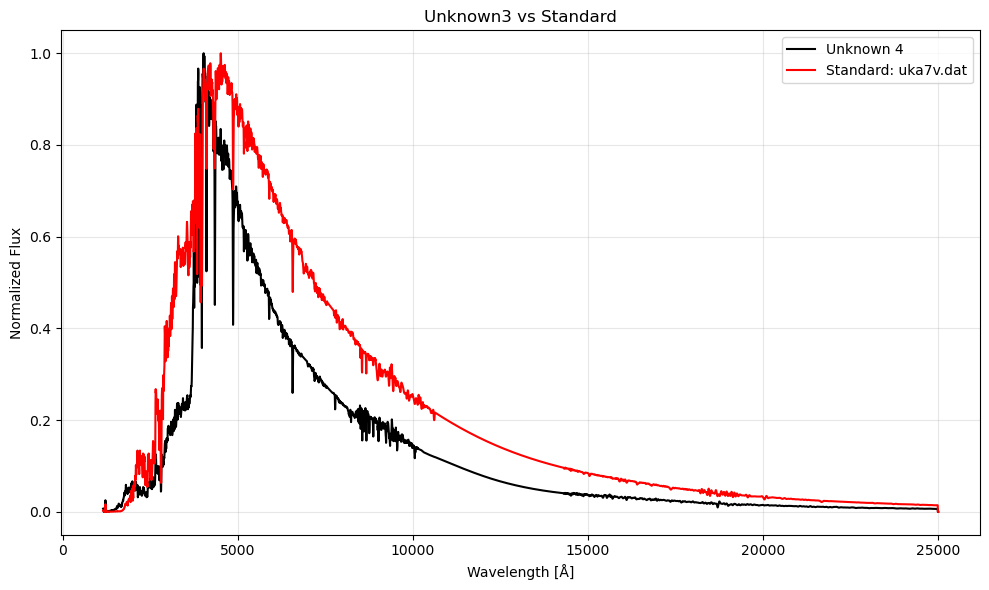

In [180]:
# this block is to find the 2 closest spectra

std_wave4, std_flux4 = load_standard("StandardSpectra/ukf5v.dat")  # change to the standard you want

# normalize both so we only compare shape, not absolute flux
unk_norm4  = unk_flux4 / unk_flux4.max()
std_norm4  = std_flux4 / std_flux4.max()

plt.figure(figsize=(10,6))
plt.plot(unk_wave4, unk_norm4, color="black", label="Unknown 4")
plt.plot(std_wave4, std_norm4, color="red", label="Standard: uka7v.dat")

plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized Flux")
plt.title("Unknown3 vs Standard")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

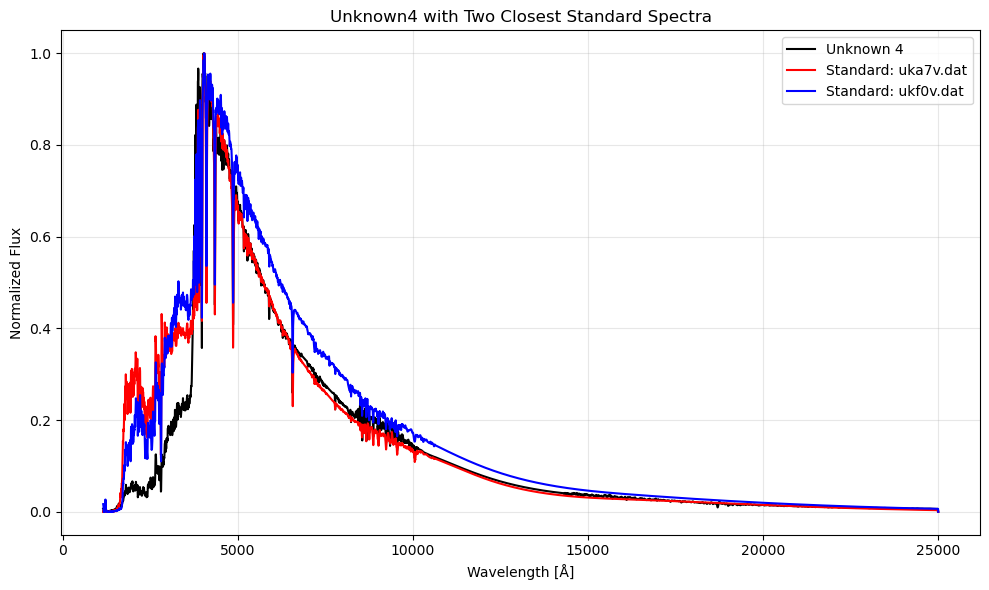

In [184]:
# this block is to plot uknown 4 with the two closest standard spectra

# unknown (we already loaded unk_wave, unk_flux)
unk_norm4 = unk_flux4 / unk_flux4.max()

# load the two closest standards
std1_wave4, std1_flux4 = load_standard("StandardSpectra/uka7v.dat")  # closest match #1
std2_wave4, std2_flux4 = load_standard("StandardSpectra/ukf0v.dat")  # closest match #2

std1_norm4 = std1_flux4 / std1_flux4.max()
std2_norm4 = std2_flux4 / std2_flux4.max()

plt.figure(figsize=(10,6))
plt.plot(unk_wave4,  unk_norm4,  color="black", label="Unknown 4")
plt.plot(std1_wave4, std1_norm4, color="red",   label="Standard: uka7v.dat")
plt.plot(std2_wave4, std2_norm4, color="blue",  label="Standard: ukf0v.dat")

plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized Flux")
plt.title("Unknown4 with Two Closest Standard Spectra")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Best-fit temperature: 8319.599986609965 K
Uncertainty: 113.8468906304449 K


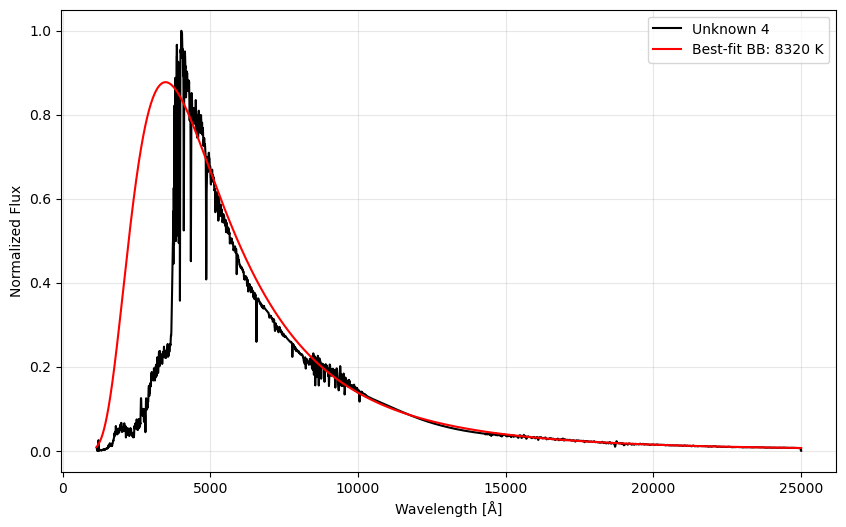

In [186]:
# this block is to plot the unknown 4 and its best fit blackbody curve

# load unknown spectrum
wave4, flux4 = load_unknown("UnknownSpectra/unknown4")

# normalize flux
flux_norm4 = flux4 / flux4.max()

# pick only continuum-like points using simple mask
mask4 = flux_norm4 > 0.5
lam_cont4  = wave4[mask4]
flux_cont4 = flux_norm4[mask4]

# fit the blackbody model
popt4, pcov4 = curve_fit(bb_model, lam_cont4, flux_cont4, p0=[20000, 1], maxfev=2000)
T_fit4, A_fit4 = popt4
T_err4 = np.sqrt(np.diag(pcov4))[0]

print("Best-fit temperature:", T_fit4, "K")
print("Uncertainty:", T_err4, "K")

# compute best-fit curve for plotting
bb_fit4 = bb_model(wave4, T_fit4, A_fit4)

# Plot
plt.figure(figsize=(10,6))
plt.plot(wave4, flux_norm4, color="black", label="Unknown 4")
plt.plot(wave4, bb_fit4,   color="red",   label=f"Best-fit BB: {T_fit4:.0f} K")
plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized Flux")
plt.legend()
plt.grid(alpha=0.3)
plt.show()